# Lesson 5 — Probability & conditional probability

*Part 1 · Lesson 5 of 20  ·  data: Titanic*

**←** [Lesson 4: Where data comes from: sampling & study design](04-where-data-comes-from.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 6: Counting: permutations & combinations](06-counting.ipynb) **→**

**Same idea, another way:**  [Another dataset →](05-probability~another-dataset.ipynb)  ·  [The code behind it →](05-probability~the-code.ipynb)

**Welcome.** Probability sounds abstract, so we'll do something concrete instead: *count real people.* Using the **887 passengers of the Titanic**, we'll see that a probability is just a fraction of a group, that "conditional" means "restrict to a subgroup," and that flipping a conditional around (the first taste of **Bayes**) can change the answer completely. We'll even watch a probability *emerge* by drawing passengers at random over and over.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it

TITANIC_URL = 'https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv'
titanic = sl.load_csv('titanic.csv', url=TITANIC_URL)

print(f'{len(titanic)} passengers, {titanic.shape[1]} columns')
titanic.head()

887 passengers, 8 columns


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## 1) Probability = favorable ÷ total

Forget formulas for a second. If I shut my eyes, reach into this list of passengers, and pull one out at random, **what's the chance they survived?** The honest answer is just bookkeeping:

$$P(\text{survived}) = \frac{\text{number who survived}}{\text{total number of passengers}}.$$

- **The math:** count the "favorable" outcomes (survivors) and divide by the total.
- **The meaning:** a probability is a *fraction of a group* — a number between 0 (never) and 1 (always).
- **The interpretation:** $P=0.39$ means *in this particular group of 887 people*, 39% survived; equivalently, a randomly grabbed passenger has a 39% chance of being a survivor.

A handy trick: the `Survived` column is already 0s and 1s, so its **mean is exactly this fraction** (the 1s are the only thing that add up).

In [2]:
n_total    = len(titanic)
n_survived = int(titanic['Survived'].sum())      # the 1s
p_survived = titanic['Survived'].mean()          # mean of 0/1 == the fraction

print(f"Survivors: {n_survived} out of {n_total}")
print(f"P(survived) = {n_survived}/{n_total} = {p_survived:.4f}")
print(f"So about {p_survived*100:.0f}% of passengers in this dataset survived.")

Survivors: 342 out of 887
P(survived) = 342/887 = 0.3856
So about 39% of passengers in this dataset survived.


## 2) Conditional probability — *restrict to a subgroup*

The single number above hides a brutal story. Let's ask a sharper question: *given that the passenger is a woman, what's the chance she survived?* That "given" is the whole idea of **conditional probability**, written $P(A \mid B)$ and read "the probability of $A$ **given** $B$."

- **The math:** there are two equivalent ways to get it.
  1. *Restrict, then count:* throw away everyone who isn't in group $B$, then compute the survival fraction among who's left.
  2. *Divide two probabilities:* $\displaystyle P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$.
- **The meaning:** the bar "$\mid B$" shrinks your world down to only the $B$ people. You're no longer asking about all passengers — just the ones who meet the condition.
- **The interpretation:** if $P(\text{survived} \mid \text{female})$ differs from $P(\text{survived})$, then knowing someone's sex *changes what you'd bet* on their survival.

Below we compute $P(\text{survived} \mid \text{female})$ **both ways** and check they agree.

In [3]:
# Way 1 — restrict to the subgroup, then take the survival rate.
women = titanic[titanic['Sex'] == 'female']
men   = titanic[titanic['Sex'] == 'male']
p_surv_given_female = women['Survived'].mean()
p_surv_given_male   = men['Survived'].mean()

# Way 2 — P(survived AND female) / P(female), using the whole dataset.
p_female              = (titanic['Sex'] == 'female').mean()
p_survived_and_female = ((titanic['Sex'] == 'female') & (titanic['Survived'] == 1)).mean()
p_via_division        = p_survived_and_female / p_female

print(f"P(survived | female), restrict & count : {p_surv_given_female:.4f}")
print(f"P(survived | female), joint / marginal : {p_via_division:.4f}   <- same number")
print()
print(f"P(survived | female) = {p_surv_given_female:.4f}")
print(f"P(survived | male)   = {p_surv_given_male:.4f}")
print(f"(compare to the overall P(survived) = {p_survived:.4f})")

P(survived | female), restrict & count : 0.7420
P(survived | female), joint / marginal : 0.7420   <- same number

P(survived | female) = 0.7420
P(survived | male)   = 0.1902
(compare to the overall P(survived) = 0.3856)


**Read that out loud.** A woman's survival chance (~74%) is nearly **four times** a man's (~19%), and both are miles from the overall 39%. "Women and children first" is not a legend here — it's printed in the arithmetic. Knowing a single fact (sex) dramatically updates the odds.

## 3) The contingency table: marginal, joint & conditional in one grid

Every probability we'll touch in this lesson lives inside one little table that cross-tabulates **Sex** against **Survived**. `pd.crosstab` builds it by counting.

In [4]:
counts = pd.crosstab(titanic['Sex'], titanic['Survived'],
                     margins=True, margins_name='Total')
counts.columns = ['Died (0)', 'Survived (1)', 'Total']
print("COUNTS — how many passengers fall in each box:")
counts

COUNTS — how many passengers fall in each box:


,Died (0),Survived (1),Total
Sex,,,
female,81,233,314
male,464,109,573
Total,545,342,887


In [5]:
# Same table as PROPORTIONS of all 887 passengers (every box / grand total).
props = pd.crosstab(titanic['Sex'], titanic['Survived'],
                    normalize=True, margins=True, margins_name='Total')
props.columns = ['Died (0)', 'Survived (1)', 'Total']
print("PROPORTIONS — each box as a fraction of everyone:")
props.round(4)

PROPORTIONS — each box as a fraction of everyone:


,Died (0),Survived (1),Total
Sex,,,
female,0.0913,0.2627,0.354
male,0.5231,0.1229,0.646
Total,0.6144,0.3856,1.000


Three different kinds of probability all live in that grid:

- **Marginal** — a probability in the *margin* (an edge total), ignoring the other variable. The bottom-right margins give $P(\text{female}) = 0.354$ and $P(\text{survived}) = 0.386$.
- **Joint** — a probability in an *inner box*: two things true at once. $P(\text{female and survived}) = 0.263$.
- **Conditional** — take an inner box and divide by a *row or column total*, which re-scales it to that subgroup: $P(\text{survived} \mid \text{female}) = 0.2627 / 0.3540 \approx 0.742$.

This is the **multiplication rule**, just rearranged:

$$P(A \text{ and } B) = P(A \mid B)\, P(B).$$

- **Meaning:** to land in both $A$ *and* $B$, first land in $B$ (chance $P(B)$), then survive the narrower bet $A$-given-$B$ (chance $P(A\mid B)$). Multiply the two gates.
- **Interpretation:** joint, conditional, and marginal are not three unrelated ideas — any one is fixed once you know the other two. Let's verify the rule numerically.

In [6]:
lhs = p_survived_and_female                 # P(survived and female), counted directly
rhs = p_surv_given_female * p_female        # P(survived | female) * P(female)

print(f"P(survived and female)            = {lhs:.4f}")
print(f"P(survived | female) * P(female)  = {rhs:.4f}")
print(f"Match? {np.isclose(lhs, rhs)}   <- the multiplication rule, confirmed by counting.")

P(survived and female)            = 0.2627
P(survived | female) * P(female)  = 0.2627
Match? True   <- the multiplication rule, confirmed by counting.


## 4) Independence — when knowing $B$ tells you *nothing*

Two events are **independent** if conditioning on one doesn't move the other:

$$P(A \mid B) = P(A) \quad\Longleftrightarrow\quad P(A \text{ and } B) = P(A)\,P(B).$$

- **Meaning:** "independent" = *no information leaks* between the two. Learning $B$ leaves your bet on $A$ exactly where it was.
- **Interpretation:** survival is *clearly not* independent of sex — we just saw $P(\text{survived}\mid\text{female})=0.742 \ne 0.386 = P(\text{survived})$. Sex carries real information about survival.

For contrast, let's manufacture something that *must* be independent: flip a fair coin for each passenger, a process that has nothing to do with the ship. Survival can't possibly depend on it, so $P(\text{survived}\mid\text{heads})$ should land right back near the overall rate.

In [7]:
# A coin flip per passenger — pure noise, unrelated to the Titanic.
coin = rng.choice(['heads', 'tails'], size=len(titanic))
titanic_coin = titanic.assign(coin=coin)

p_surv_given_heads = titanic_coin.loc[titanic_coin['coin'] == 'heads', 'Survived'].mean()
p_surv_given_tails = titanic_coin.loc[titanic_coin['coin'] == 'tails', 'Survived'].mean()

print(f"P(survived)               = {p_survived:.4f}")
print(f"P(survived | coin=heads)  = {p_surv_given_heads:.4f}   <- ~the same (independent)")
print(f"P(survived | coin=tails)  = {p_surv_given_tails:.4f}   <- ~the same (independent)")
print()
print("Sex MOVES the survival rate a lot; a coin flip barely nudges it.")
print(f"  conditioning on sex  : {p_surv_given_female:.3f} vs {p_surv_given_male:.3f}  (huge gap)")
print(f"  conditioning on coin : {p_surv_given_heads:.3f} vs {p_surv_given_tails:.3f}  (tiny gap)")

P(survived)               = 0.3856
P(survived | coin=heads)  = 0.4130   <- ~the same (independent)
P(survived | coin=tails)  = 0.3596   <- ~the same (independent)

Sex MOVES the survival rate a lot; a coin flip barely nudges it.
  conditioning on sex  : 0.742 vs 0.190  (huge gap)
  conditioning on coin : 0.413 vs 0.360  (tiny gap)


The small leftover gap for the coin isn't dependence — it's just **sampling wiggle** from a finite group of 887. Change the seed in the setup cell and that gap will jiggle around zero, while the sex gap stays enormous no matter what.

## 5) A conditional *gradient*: survival by passenger class

Conditioning isn't limited to two groups. Splitting survival by ticket **class** (1st, 2nd, 3rd) gives three conditional probabilities — and a stark gradient.

P(survived | Pclass=1) = 0.6296
P(survived | Pclass=2) = 0.4728
P(survived | Pclass=3) = 0.2444


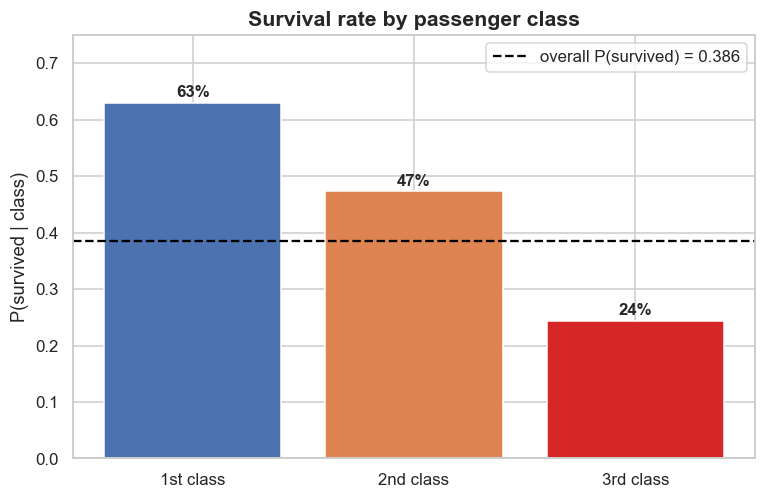

In [8]:
class_rates = titanic.groupby('Pclass')['Survived'].mean()
for c, r in class_rates.items():
    print(f"P(survived | Pclass={c}) = {r:.4f}")

fig, ax = plt.subplots()
bars = ax.bar(['1st class', '2nd class', '3rd class'], class_rates.values,
              color=['#4c72b0', '#dd8452', '#d62728'], edgecolor='white')
ax.axhline(p_survived, color='black', ls='--', lw=1.5,
           label=f'overall P(survived) = {p_survived:.3f}')
for b, r in zip(bars, class_rates.values):
    ax.text(b.get_x() + b.get_width()/2, r + 0.01, f'{r:.0%}', ha='center', fontweight='bold')
ax.set_ylabel('P(survived | class)'); ax.set_ylim(0, 0.75)
ax.set_title('Survival rate by passenger class')
ax.legend(); plt.show()

**Interpretation:** a first-class passenger's survival chance (~63%) is more than **double** a third-class passenger's (~24%). Class — a proxy for wealth, deck location, and access to lifeboats — conditions survival almost as forcefully as sex does. The dashed line is the overall rate; every bar sits well above or below it, which is exactly what "not independent" looks like.

## 6) A first taste of Bayes — flipping the conditional

Here is the subtle trap that fools experts. We found $P(\text{survived} \mid \text{female}) = 0.742$. Does that mean a survivor was probably a woman, $P(\text{female} \mid \text{survived})$? **These are different questions**, and in general

$$P(A \mid B) \ne P(B \mid A).$$

**Bayes' theorem** is the exact recipe for turning one around into the other:

$$P(\text{female} \mid \text{survived}) = \frac{P(\text{survived} \mid \text{female})\; P(\text{female})}{P(\text{survived})}.$$

- **The math:** multiply the conditional you *have* by the marginal of its condition, then divide by the marginal of the thing you conditioned *on*.
- **The meaning:** it re-weights "$P(\text{survived}\mid\text{female})$" by how common women were to begin with ($P(\text{female})$) and how common survival was overall ($P(\text{survived})$).
- **The interpretation:** it answers a *backwards* question — "we know they survived; how likely is it they were a woman?" — which is a genuinely different fact about the world than the forward one.

Let's compute it from the three ingredients, then check it against the table directly.

In [9]:
# Bayes: flip P(survived|female) into P(female|survived).
p_female_given_survived_bayes = (p_surv_given_female * p_female) / p_survived

# Direct check: among survivors only, what fraction were female?
survivors = titanic[titanic['Survived'] == 1]
p_female_given_survived_direct = (survivors['Sex'] == 'female').mean()

print(f"P(survived | female)              = {p_surv_given_female:.4f}")
print(f"P(female | survived) via Bayes    = {p_female_given_survived_bayes:.4f}")
print(f"P(female | survived) from counting= {p_female_given_survived_direct:.4f}   <- matches Bayes")
print()
print("Punchline:  P(survived | female) = 0.742  but  P(female | survived) = 0.681.")
print("Same two events, opposite condition, DIFFERENT numbers. Order matters!")

P(survived | female)              = 0.7420
P(female | survived) via Bayes    = 0.6813
P(female | survived) from counting= 0.6813   <- matches Bayes

Punchline:  P(survived | female) = 0.742  but  P(female | survived) = 0.681.
Same two events, opposite condition, DIFFERENT numbers. Order matters!


Why are they so different? Because the two questions are weighted by *different* **base rates** (a base rate is just how common each group is to begin with). $0.742$ is computed inside the (smaller) world of women; $0.681$ is computed inside the world of survivors, which also contains the lucky men. Bayes is just the machinery that respects those base rates when you flip the question — we'll build a whole lesson on it later.

## 7) Watching a probability *happen*: the long-run frequency

We *defined* probability as a fraction of the whole group. But there's a second, deeper meaning: a probability is the value a relative frequency **settles toward** as you repeat a random draw more and more. This is the **law of large numbers**, and we can literally watch it.

The experiment: draw passengers one at a time **at random with replacement** (put each back so the deck is always full), and after each draw recompute "fraction of survivors so far." Early on it lurches; with enough draws it homes in on the true $P(\text{survived}) = 0.386$.

After    10 draws: running P(survived) = 0.6000
After   100 draws: running P(survived) = 0.5100
After  4000 draws: running P(survived) = 0.3880
True (whole-group) P(survived)           = 0.3856


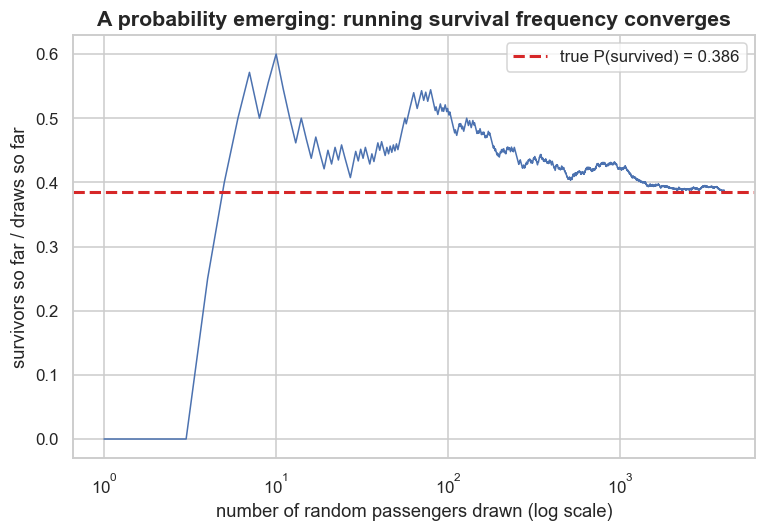

In [10]:
n_draws = 4000                       # tinker: try 200, or 20000
picks = rng.choice(titanic['Survived'].to_numpy(), size=n_draws, replace=True)
running_freq = np.cumsum(picks) / np.arange(1, n_draws + 1)   # survivors-so-far / draws-so-far

print(f"After    10 draws: running P(survived) = {running_freq[9]:.4f}")
print(f"After   100 draws: running P(survived) = {running_freq[99]:.4f}")
print(f"After  {n_draws} draws: running P(survived) = {running_freq[-1]:.4f}")
print(f"True (whole-group) P(survived)           = {p_survived:.4f}")

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_draws + 1), running_freq, color='#4c72b0', lw=1)
ax.axhline(p_survived, color='#d62728', ls='--', lw=2,
           label=f'true P(survived) = {p_survived:.3f}')
ax.set_xscale('log')   # log x-axis so the early lurching and late settling both show
ax.set_xlabel('number of random passengers drawn (log scale)')
ax.set_ylabel('survivors so far / draws so far')
ax.set_title('A probability emerging: running survival frequency converges')
ax.legend(); plt.show()

**Interpretation:** the jagged blue line is *one* run of the experiment; the red line is the truth it's chasing. The wild swings at the left (few draws) are why small samples mislead, and the calm approach on the right is why large samples are trustworthy. This convergence is the bridge from "probability is a fraction" to the sampling lessons coming up — it's the engine under the whole rest of the course.

## Now you try

Predict the answer first, then change one thing and re-run:

1. **First-class women.** Add a new cell (the **+** button in the toolbar), paste this line, and run it with Shift+Enter:

       titanic[(titanic['Sex'] == 'female') & (titanic['Pclass'] == 1)]['Survived'].mean()

   Will it be higher or lower than the 0.742 for women overall? (It's startling.)
2. **Break the convergence.** In §7 set `n_draws = 50`. Does the blue line reliably reach the red line now? Re-run a few times — how much does the final number bounce? Then try `n_draws = 30000`.
3. **A real conditional, not a coin.** Repeat §4 but condition on having family aboard: compare `titanic[titanic['Siblings/Spouses Aboard'] > 0]['Survived'].mean()` to the overall rate. Independent like the coin, or dependent like sex?

## What you learned

- **Probability is favorable ÷ total** — a fraction of a group between 0 and 1. For a 0/1 column it's just the `.mean()`.
- **Conditional probability $P(A\mid B)$** shrinks the world to the subgroup $B$; compute it by restricting-and-counting *or* as $P(A\text{ and }B)/P(B)$ — same answer.
- A **contingency table** holds **marginal** (edge), **joint** (inner box), and **conditional** (box ÷ margin) probabilities, tied together by the **multiplication rule** $P(A\text{ and }B)=P(A\mid B)P(B)$.
- **Independence** means conditioning changes nothing ($P(A\mid B)=P(A)$); survival depends strongly on **sex** and **class** but not on a **coin flip**.
- **Bayes flips a conditional:** $P(A\mid B)\ne P(B\mid A)$ in general, and the **law of large numbers** shows a probability emerging as a running frequency settles toward its true value.

---

**← Previous:** [Lesson 4: Where data comes from: sampling & study design](04-where-data-comes-from.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 6: Counting: permutations & combinations](06-counting.ipynb)

**Same idea, another way:**  [Another dataset →](05-probability~another-dataset.ipynb)  ·  [The code behind it →](05-probability~the-code.ipynb)